# Exploring the Parameter Space

Before calibrating an agent-based model, it is useful to understand how the model behaves across different parameter values.

In this notebook, we use the **Wolf–Sheep Predation model** to explore:

- how model behaviour changes when parameters change;
- how to sample efficiently from a multidimensional parameter space;
- how stochasticity affects model outputs; and
- whether different parameter combinations can produce similar outcomes.

> **Exploration helps us understand the model before asking an algorithm to calibrate it.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import qmc

from caliagent.models import WolfSheep

## The Wolf–Sheep Model

The Wolf–Sheep model represents individual sheep and wolves interacting within a shared environment.

Unlike the Lotka–Volterra model, population-level behaviour **emerges from the actions of individual agents**.

We will explore five parameters:

| Parameter | Description |
| --- | --- |
| `sheep_reproduce` | Probability of sheep reproducing |
| `wolf_reproduce` | Probability of wolves reproducing |
| `wolf_gain_from_food` | Energy gained by a wolf after eating a sheep |
| `grass_regrowth_time` | Time required for grass to regrow |
| `sheep_gain_from_food` | Energy gained by a sheep from eating grass |

For this notebook, we will primarily examine the **sheep population**.

In [135]:
N_STEPS = 250
N_REPLICATES = 20

INITIAL_SHEEP = 150
INITIAL_WOLVES = 5

## Running the Model

We first define a small helper function for running the Wolf–Sheep model.

The function records the sheep population through time.

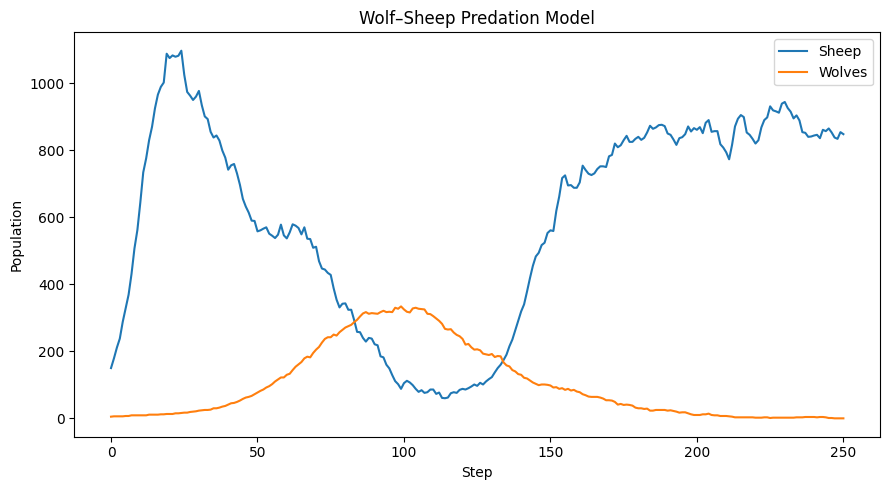

In [136]:
def simulate(
    sheep_reproduce=0.2,
    wolf_reproduce=0.05,
    wolf_gain_from_food=12,
    grass_regrowth_time=5,
    sheep_gain_from_food=12,
    seed=None,
):
    """Run one Wolf-Sheep simulation and return the population trajectory."""

    model = WolfSheep(
        initial_sheep=INITIAL_SHEEP,
        initial_wolves=INITIAL_WOLVES,
        grass=True,
        sheep_reproduce=sheep_reproduce,
        wolf_reproduce=wolf_reproduce,
        wolf_gain_from_food=wolf_gain_from_food,
        grass_regrowth_time=int(round(grass_regrowth_time)),
        sheep_gain_from_food=sheep_gain_from_food,
        seed=seed,
    )

    sheep = np.empty(N_STEPS + 1)
    wolves = np.empty(N_STEPS + 1)

    sheep[0] = model.sheep_count
    wolves[0] = model.wolf_count

    for step in range(1, N_STEPS + 1):
        model.step()

        sheep[step] = model.sheep_count
        wolves[step] = model.wolf_count

    return pd.DataFrame(
        {
            "step": np.arange(N_STEPS + 1),
            "sheep": sheep,
            "wolves": wolves,
        }
    )

baseline = simulate(seed=1)

plt.figure(figsize=(9, 5))

plt.plot(
    baseline["step"],
    baseline["sheep"],
    label="Sheep",
)

plt.plot(
    baseline["step"],
    baseline["wolves"],
    label="Wolves",
)

plt.xlabel("Step")
plt.ylabel("Population")
plt.title("Wolf–Sheep Predation Model")
plt.legend()
plt.tight_layout()
plt.show()

## Why Explore Before Calibrating?

Each model parameter has a range of plausible values.

Together, these ranges define the model's **parameter space**.

Exploring this space helps us:

- understand how model behaviour changes;
- identify unusual or implausible regions; and
- see whether different parameter combinations can produce similar outcomes.

In [138]:
problem = {
    "names": [
        "sheep_reproduce",
        "wolf_reproduce",
        "wolf_gain_from_food",
        "grass_regrowth_time",
        "sheep_gain_from_food",
    ],
    "bounds": [
        [0.01, 0.30],
        [0.01, 0.30],
        [5.0, 30.0],
        [5.0, 30.0],
        [1.0, 30.0],
    ],
}

## One Parameter at a Time

A simple way to begin exploring a model is to change **one parameter while holding the others fixed**.

Here, we vary `wolf_gain_from_food`.

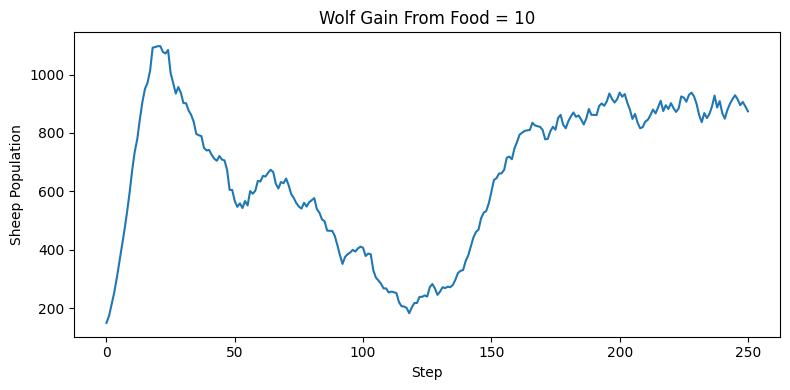

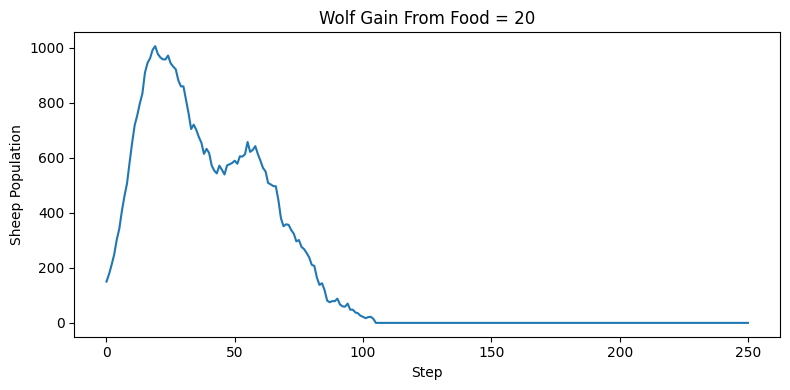

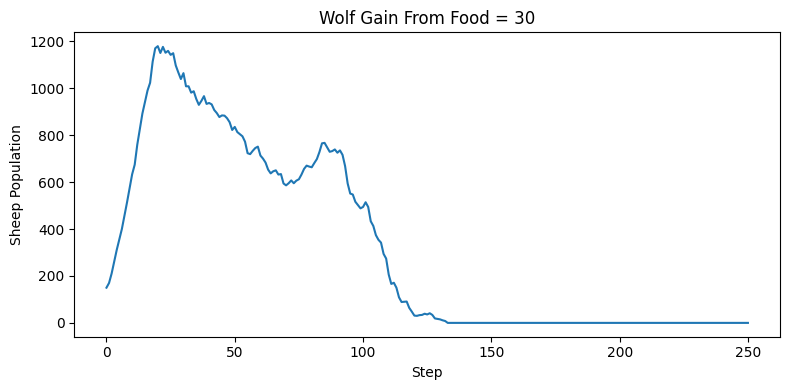

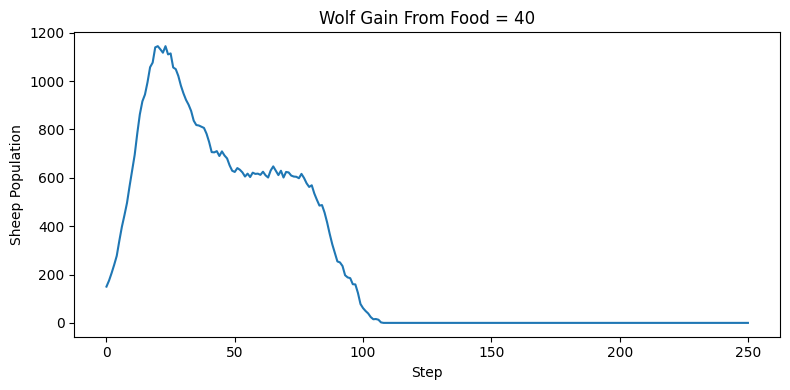

In [139]:
wolf_gain_values = [10, 20, 30, 40]

for wolf_gain in wolf_gain_values:
    result = simulate(
        wolf_gain_from_food=wolf_gain,
        seed=1,
    )

    plt.figure(figsize=(8, 4))

    plt.plot(
        result["step"],
        result["sheep"],
    )

    plt.xlabel("Step")
    plt.ylabel("Sheep Population")
    plt.title(
        f"Wolf Gain From Food = {wolf_gain}"
    )

    plt.tight_layout()
    plt.show()

Changing one parameter at a time is useful for building intuition, but it does not efficiently explore combinations of several parameters.

For models with many parameters, we need a more systematic sampling strategy.

## Space-Filling Designs

Suppose we want to explore all five parameters simultaneously.

Random sampling is simple, but it can leave some regions of the parameter space poorly represented.

**Latin Hypercube Sampling (LHS)** is a space-filling design that spreads samples more evenly across each parameter range.

In [183]:
N_SAMPLES = 250
N_PARAMETERS = len(problem["names"])

rng = np.random.default_rng(42)

random_unit = rng.random(
    (N_SAMPLES, N_PARAMETERS)
)

lhs_sampler = qmc.LatinHypercube(
    d=N_PARAMETERS,
    seed=42,
)

lhs_unit = lhs_sampler.random(
    n=N_SAMPLES
)

lower = np.array(
    [bounds[0] for bounds in problem["bounds"]]
)

upper = np.array(
    [bounds[1] for bounds in problem["bounds"]]
)

random_samples = qmc.scale(
    random_unit,
    lower,
    upper,
)

lhs_samples = qmc.scale(
    lhs_unit,
    lower,
    upper,
)

### Random Sampling vs Latin Hypercube Sampling

Because the full parameter space has five dimensions, we cannot display it directly.

Instead, we can examine one or two dimensions at a time.

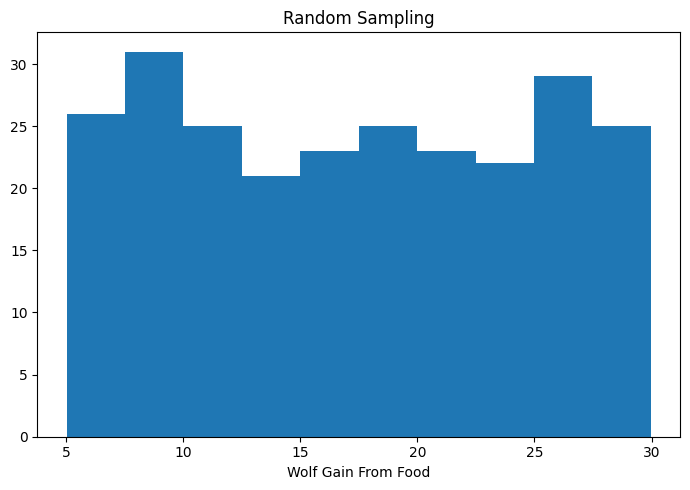

In [184]:
plt.figure(figsize=(7, 5))

plt.hist(
    random_samples[:, 2],
)

plt.xlabel("Number of Samples")
plt.xlabel("Wolf Gain From Food")
plt.title("Random Sampling")

plt.tight_layout()
plt.show()

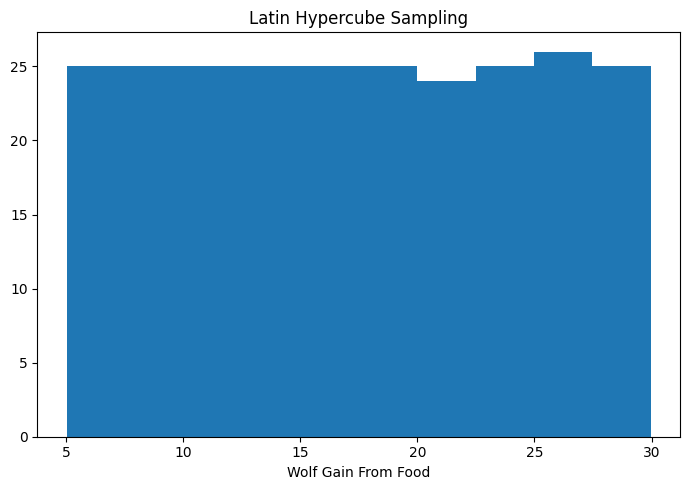

In [185]:
plt.figure(figsize=(7, 5))

plt.hist(
    lhs_samples[:, 2],
)

plt.xlabel("Number of Samples")
plt.xlabel("Wolf Gain From Food")
plt.title("Latin Hypercube Sampling")

plt.tight_layout()
plt.show()

Both methods explore the parameter space, but Latin hypercube sampling is designed to provide **more even coverage of each parameter range**.

This can be particularly useful when simulations are expensive and we want to make efficient use of a limited simulation budget.

## Running the Parameter Exploration

For each parameter combination generated by the Latin hypercube design, we run the model several times.

Because the Wolf–Sheep model is stochastic, the same parameter values can produce different population trajectories.

We therefore calculate the **mean sheep and wolf populations at each timestep across replicate simulations**.

This gives us a representative predator–prey trajectory for each parameter combination while reducing some of the stochastic variation between individual simulations.

In [186]:
def evaluate_trajectory(
    params,
    n_replicates=N_REPLICATES,
):
    """Mean sheep and wolf trajectories across replicate simulations."""

    (
        sheep_reproduce,
        wolf_reproduce,
        wolf_gain_from_food,
        grass_regrowth_time,
        sheep_gain_from_food,
    ) = params

    sheep_trajectories = np.empty(
        (n_replicates, N_STEPS + 1)
    )

    wolf_trajectories = np.empty(
        (n_replicates, N_STEPS + 1)
    )

    for replicate in range(n_replicates):
        result = simulate(
            sheep_reproduce=sheep_reproduce,
            wolf_reproduce=wolf_reproduce,
            wolf_gain_from_food=wolf_gain_from_food,
            grass_regrowth_time=grass_regrowth_time,
            sheep_gain_from_food=sheep_gain_from_food,
            seed=replicate,
        )

        sheep_trajectories[replicate] = (
            result["sheep"].to_numpy()
        )

        wolf_trajectories[replicate] = (
            result["wolves"].to_numpy()
        )

    return {
        "sheep": sheep_trajectories.mean(axis=0),
        "wolves": wolf_trajectories.mean(axis=0),
    }

results = [
    evaluate_trajectory(params)
    for params in lhs_samples
]

mean_sheep_trajectories = np.array([
    result["sheep"]
    for result in results
])

mean_wolf_trajectories = np.array([
    result["wolves"]
    for result in results
])

## How Does Model Behaviour Vary Across the Parameter Space?

Each parameter combination in our Latin hypercube design produces a different predator–prey system.

The plots below show the mean sheep and wolf population trajectories generated across the parameter space.

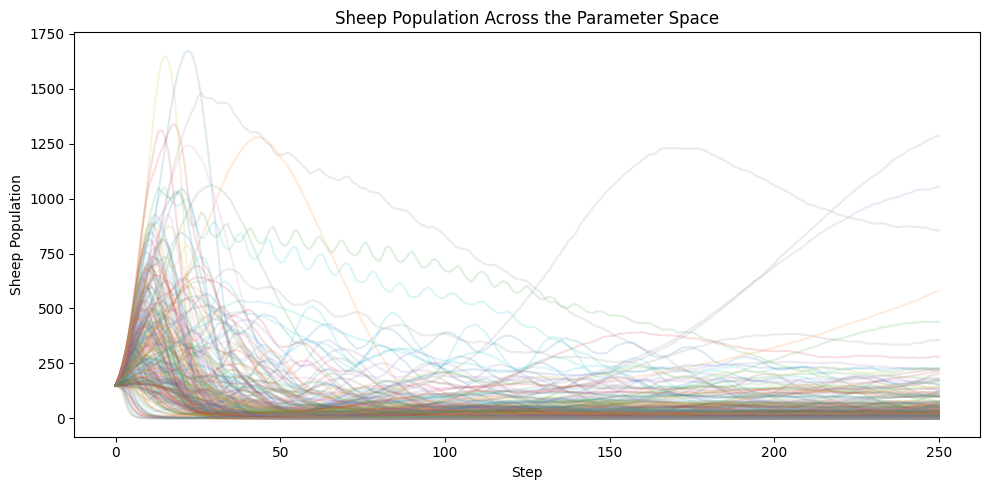

In [187]:
steps = np.arange(N_STEPS + 1)

plt.figure(figsize=(10, 5))

for trajectory in mean_sheep_trajectories:
    plt.plot(
        steps,
        trajectory,
        alpha=0.15,
    )

plt.xlabel("Step")
plt.ylabel("Sheep Population")
plt.title(
    "Sheep Population Across the Parameter Space"
)

plt.tight_layout()
plt.show()

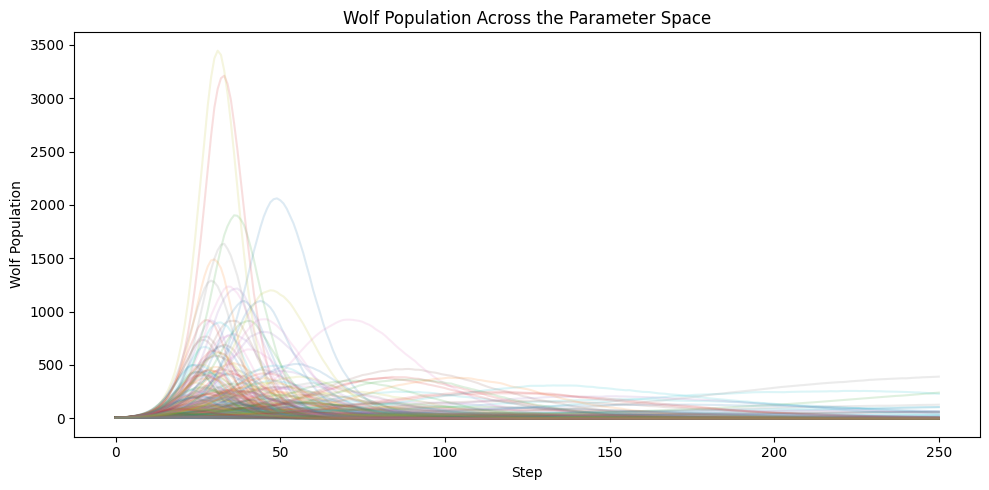

In [188]:
plt.figure(figsize=(10, 5))

for trajectory in mean_wolf_trajectories:
    plt.plot(
        steps,
        trajectory,
        alpha=0.15,
    )

plt.xlabel("Step")
plt.ylabel("Wolf Population")
plt.title(
    "Wolf Population Across the Parameter Space"
)

plt.tight_layout()
plt.show()

The range of trajectories shows that changing the model parameters can produce substantially different predator–prey dynamics.

Some parameter combinations maintain both populations, while others may lead to rapid population growth or population collapse.

This gives us an initial picture of the range of behaviours that can emerge from different regions of the parameter space.

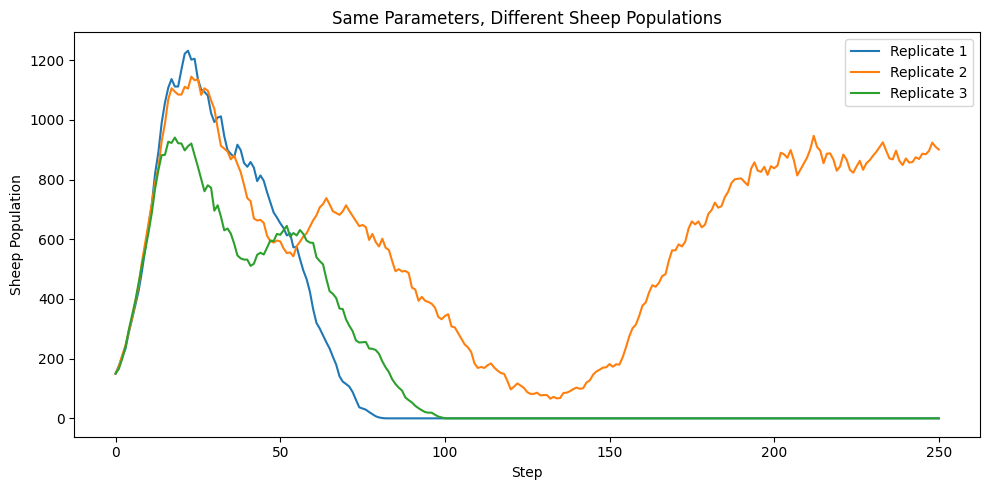

In [189]:
example_parameters = {
    "sheep_reproduce": 0.2,
    "wolf_reproduce": 0.05,
    "wolf_gain_from_food": 12.0,
    "grass_regrowth_time": 5,
    "sheep_gain_from_food": 12.0,
}

replicate_trajectories = [
    simulate(
        **example_parameters,
        seed=seed,
    )
    for seed in range(3)
]

plt.figure(figsize=(10, 5))

for i, result in enumerate(
    replicate_trajectories,
    start=1,
):
    plt.plot(
        result["step"],
        result["sheep"],
        label=f"Replicate {i}",
    )

plt.xlabel("Step")
plt.ylabel("Sheep Population")
plt.title(
    "Same Parameters, Different Sheep Populations"
)

plt.legend()
plt.tight_layout()
plt.show()

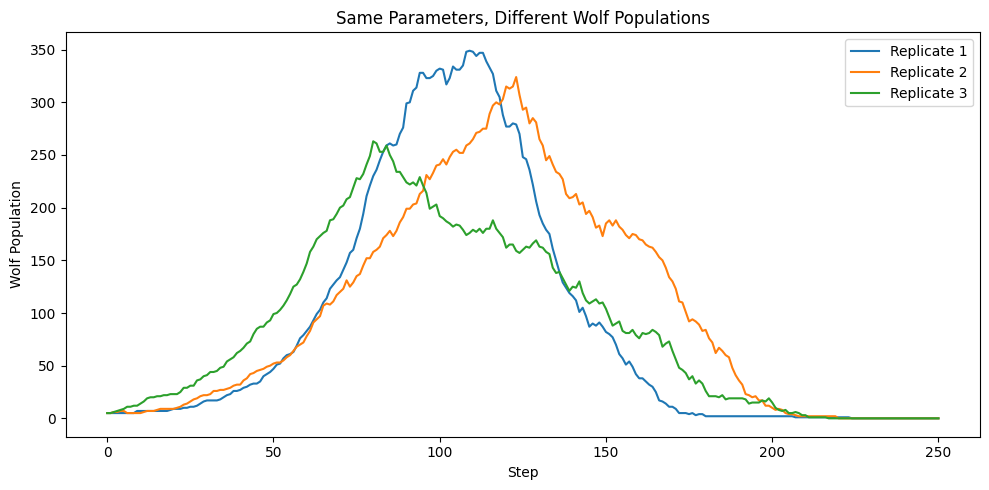

In [190]:
plt.figure(figsize=(10, 5))

for i, result in enumerate(
    replicate_trajectories,
    start=1,
):
    plt.plot(
        result["step"],
        result["wolves"],
        label=f"Replicate {i}",
    )

plt.xlabel("Step")
plt.ylabel("Wolf Population")
plt.title(
    "Same Parameters, Different Wolf Populations"
)

plt.legend()
plt.tight_layout()
plt.show()

## Combining Replicate Simulations

One way to describe the typical behaviour of a stochastic model is to calculate the **average population at each timestep across replicate simulations**.

This produces mean sheep and wolf trajectories while reducing some of the random variation between individual simulations.

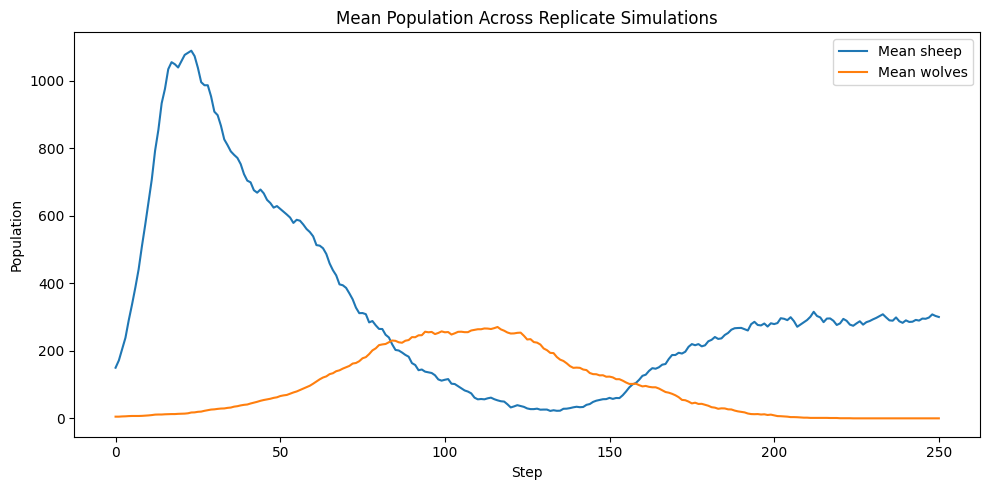

In [191]:
sheep_replicates = np.array([
    result["sheep"].to_numpy()
    for result in replicate_trajectories
])

wolf_replicates = np.array([
    result["wolves"].to_numpy()
    for result in replicate_trajectories
])

mean_sheep = sheep_replicates.mean(
    axis=0
)

mean_wolves = wolf_replicates.mean(
    axis=0
)

plt.figure(figsize=(10, 5))

plt.plot(
    steps,
    mean_sheep,
    label="Mean sheep",
)

plt.plot(
    steps,
    mean_wolves,
    label="Mean wolves",
)

plt.xlabel("Step")
plt.ylabel("Population")
plt.title(
    "Mean Population Across Replicate Simulations"
)

plt.legend()
plt.tight_layout()
plt.show()

## Looking for Equifinality

We have seen that repeated simulations with the **same parameters can produce different outcomes** because the model is stochastic.

Now we ask the opposite question:

> **Can different parameter combinations produce similar predator–prey dynamics?**

This is known as **equifinality**.

Our Latin hypercube exploration has generated many different combinations of model parameters. For each combination, we have also generated mean sheep and wolf population trajectories.

We can therefore:

1. Define target sheep and wolf trajectories.
2. Measure how closely each sampled parameter combination reproduces those trajectories.
3. Identify several parameter combinations that produce similarly good fits.
4. Compare their parameter values.

If **substantially different parameter combinations produce similarly good fits to the target trajectories**, this provides evidence of equifinality.

Importantly, finding the single best-fitting parameter combination would not demonstrate equifinality. We are interested in whether **multiple different combinations can explain the same observed behaviour**.

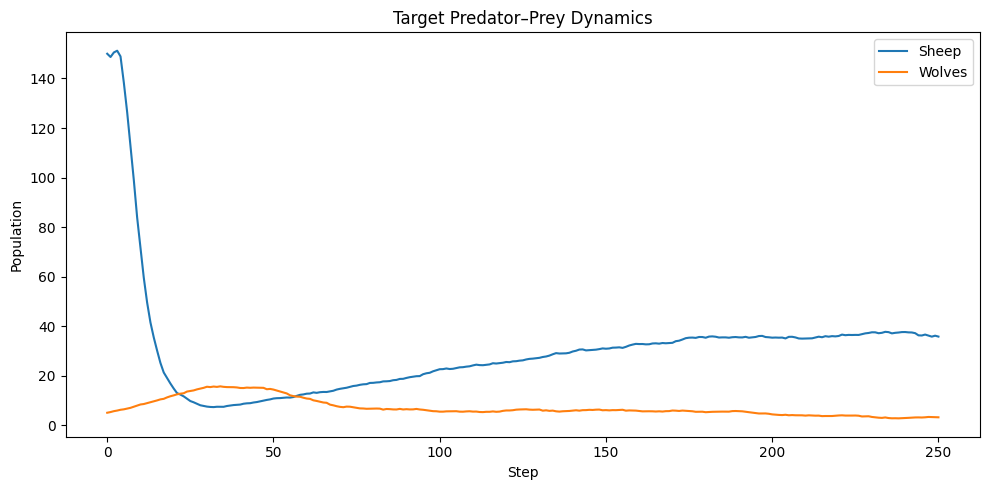

In [192]:
target_parameters = {
    "sheep_reproduce": 0.05,
    "wolf_reproduce": 0.05,
    "wolf_gain_from_food": 20.0,
    "grass_regrowth_time": 30,
    "sheep_gain_from_food": 4.0,
}

target = evaluate_trajectory(
    list(target_parameters.values()),
    n_replicates=50,
)

target_sheep = target["sheep"]
target_wolves = target["wolves"]

plt.figure(figsize=(10, 5))

plt.plot(
    steps,
    target_sheep,
    label="Sheep",
)

plt.plot(
    steps,
    target_wolves,
    label="Wolves",
)

plt.xlabel("Step")
plt.ylabel("Population")
plt.title("Target Predator–Prey Dynamics")

plt.legend()
plt.tight_layout()
plt.show()

## Measuring Similarity

We compare both the sheep and wolf trajectories with their corresponding target trajectories.

Because sheep and wolf populations can occur on different scales, we calculate their errors separately and then combine them.

Smaller values indicate a closer overall match to the target predator–prey dynamics.

In [193]:
sheep_error = np.mean(
    (
        mean_sheep_trajectories
        - target_sheep
    ) ** 2,
    axis=1,
) / np.var(target_sheep)

wolf_error = np.mean(
    (
        mean_wolf_trajectories
        - target_wolves
    ) ** 2,
    axis=1,
) / np.var(target_wolves)

errors = (
    sheep_error
    + wolf_error
)

exploration = pd.DataFrame(
    lhs_samples,
    columns=problem["names"],
)

exploration["error"] = errors

best_indices = np.argsort(
    errors
)[:5]

best_fits = (
    exploration
    .iloc[best_indices]
    .copy()
)

best_fits

,sheep_reproduce,wolf_reproduce,wolf_gain_from_food,grass_regrowth_time,sheep_gain_from_food,error
51,0.031175,0.020653,20.789472,7.593344,1.279046,1.107054
36,0.013607,0.027524,13.548114,20.168407,3.230447,1.753420
220,0.101631,0.124450,18.920249,19.016083,2.143954,1.817875
178,0.059486,0.049492,9.075640,27.790108,4.740593,2.765599
92,0.094016,0.125832,22.505398,24.869866,2.556950,3.348564


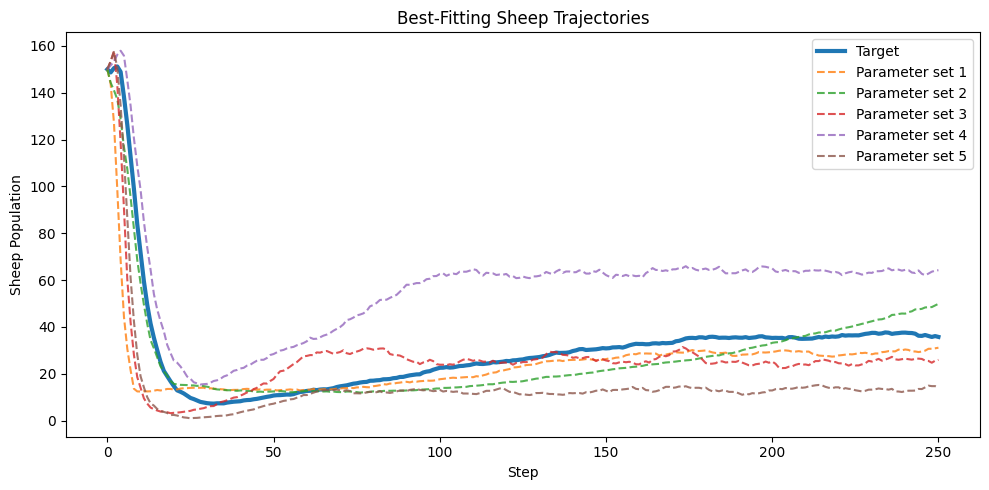

In [195]:
plt.figure(figsize=(10, 5))

plt.plot(
    steps,
    target_sheep,
    linewidth=3,
    label="Target",
)

for rank, index in enumerate(
    best_indices,
    start=1,
):
    plt.plot(
        steps,
        mean_sheep_trajectories[index],
        linestyle="--",
        alpha=0.8,
        label=f"Parameter set {rank}",
    )

plt.xlabel("Step")
plt.ylabel("Sheep Population")
plt.title(
    "Best-Fitting Sheep Trajectories"
)

plt.legend()
plt.tight_layout()
plt.show()

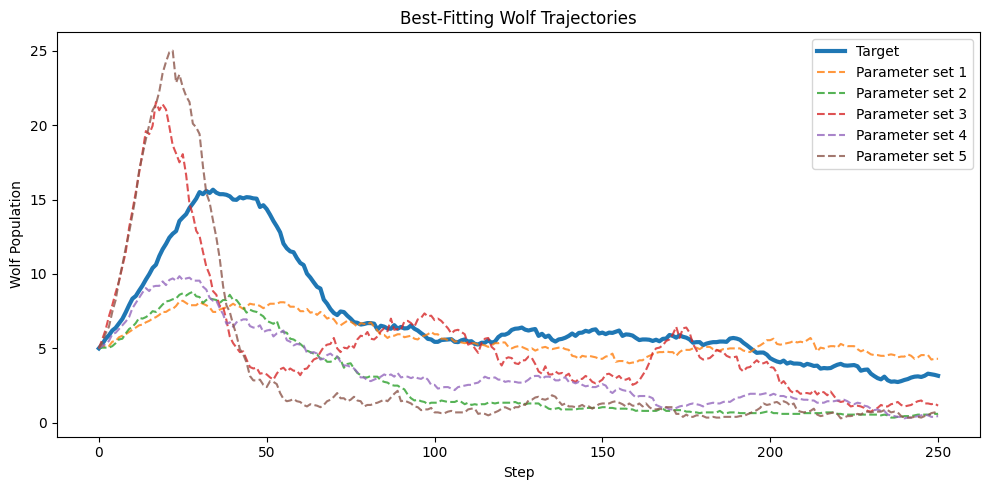

In [196]:
plt.figure(figsize=(10, 5))

plt.plot(
    steps,
    target_wolves,
    linewidth=3,
    label="Target",
)

for rank, index in enumerate(
    best_indices,
    start=1,
):
    plt.plot(
        steps,
        mean_wolf_trajectories[index],
        linestyle="--",
        alpha=0.8,
        label=f"Parameter set {rank}",
    )

plt.xlabel("Step")
plt.ylabel("Wolf Population")
plt.title(
    "Best-Fitting Wolf Trajectories"
)

plt.legend()
plt.tight_layout()
plt.show()

## What Have We Learned?

Parameter-space exploration helps us understand the model before calibration.

In this notebook we found that:

- different parameter combinations can produce different predator–prey dynamics;
- **Latin hypercube sampling** provides a systematic way to explore several parameters simultaneously;
- repeated simulations with the same parameters can produce different outcomes;
- **replicate sampling** helps us estimate typical model behaviour; and
- different parameter combinations can produce similar sheep and wolf trajectories (**equifinality**).

> **Exploration shows how different regions of parameter space affect model behaviour.**